In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math
import joblib
import torch
import torch.nn as nn
import torchvision
import deepRD.tools.trajectoryTools as trajectoryTools
import deepRD.tools.analysisTools as analysisTools
from torch.utils.data import Dataset, DataLoader
from torch import optim
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from scipy.stats import gaussian_kde

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=(128,128)):
        super().__init__()
        layers, d = [], in_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.SiLU(), nn.LayerNorm(h)]
            d = h
        layers += [nn.Linear(d, out_dim)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

def reparam(mu, logvar, Tz=1.0):
    eps = torch.randn_like(mu)
    return mu + eps * torch.exp(0.5 * logvar) * Tz

class DiagGaussianHead(nn.Module):
    """Outputs (mu, log_sigma) for R^3."""
    def __init__(self, in_dim, out_dim):
        super().__init__()
        assert out_dim % 2 == 0, "out_dim must be even: 2 * D"
        self.D = out_dim//2
        self.mlp = MLP(in_dim, out_dim, hidden=(128,128))
    def forward(self, x):
        out = self.mlp(x)
        mu, log_sig = out[..., :self.D], out[..., self.D:]
        return mu, log_sig

# ---------- CVAE ----------
class CVAE(nn.Module):
    def __init__(self, zdim=3, system_type="bistable", cond_type="piri"):
        super().__init__()
        
        assert system_type in ("bistable", "dimer")
        assert cond_type in ("piri", "piririm", "pipimri", "pidqiri", "dqidpiri", "dqidpiririm")
        self.system_type = system_type
        self.cond_type = cond_type
        self.zdim = zdim
        
        if system_type=="bistable":
            self.idim = 3
            if cond_type == "piri":
                self.cdim = 6
            elif cond_type in ("piririm", "pipimri"):
                self.cdim = 9
                
        elif system_type=="dimer":
            self.idim = 6
            if cond_type == "piri":
                self.cdim = 12
            elif cond_type == "pidqiri":
                self.cdim = 13 
            elif cond_type == "dqidpiri":
                self.cdim = 8
            elif cond_type == "dqidpiririm":
                self.cdim = 14
        
        # networks
        self.encoder = MLP(self.idim + self.cdim, out_dim=2*zdim, hidden=(128,128))
        self.prior   = MLP(self.cdim, out_dim=2*zdim, hidden=(128,128))
        self.decoder = DiagGaussianHead(zdim + self.cdim, 2*self.idim)
        
        # normalisers
        self.scaler_r = None
        self.scaler_c = None
        
    def attach_normalizers(self, scaler_r, scaler_c):
        """Attach normalization scalers for automatic preprocessing."""
        self.scaler_r = scaler_r
        self.scaler_c = scaler_c

    def encode(self, r_next, c):
        q = self.encoder(torch.cat([r_next, c], dim=-1))
        q_mu, q_logv = q.split(self.zdim, dim=-1)
        return q_mu, q_logv

    def prior_params(self, c):
        p = self.prior(c)
        p_mu, p_logv = p.split(self.zdim, dim=-1)
        return p_mu, p_logv

    def decode(self, z, c):
        mu, log_sig = self.decoder(torch.cat([z, c], dim=-1))
        return mu, log_sig

    def forward(self, r_next, c):
        p_mu, p_logv = self.prior_params(c)
        q_mu, q_logv = self.encode(r_next, c)
        z = reparam(q_mu, q_logv)
        dec_out = self.decode(z, c)
        return dec_out, (q_mu, q_logv), (p_mu, p_logv)   
    
    # ----- sampling ----- #
    @torch.no_grad()
    def sample_torch(self, c, Tr=1.0, Tz=1.0):
        """
        Sampling from torch tensor, no (de)normalisation.
        """
        p_mu, p_logv = self.prior_params(c)
        z = reparam(p_mu, p_logv, Tz=Tz)  # sample from p(z|c)
        
        mu, log_sig = self.decode(z, c)
        r = mu + torch.exp(log_sig) * torch.randn_like(mu) * Tr
        return r
    
    @torch.no_grad()
    def sample(self, c_n_np, Tr=1.0, Tz=1.0, device=None):
        """
        Sample r_{n+1} in physical units given c_n_np in physical units as NumPy array. 
        Built in normalisation of input and denormalisation of output.

        Args:
            c_n_np (np.ndarray): shape (..., cdim)
            Tr (float): temperature scaling factor for stochasticity
            Tz (float): temperature scaling factor in latent space for stochasticity
            device (torch.device): GPU/CPU device to use (optional)
            
        Handles every conditioning type provided the corresponding scaler.

        Returns:
            np.ndarray: generated r_{n+1} in same physical scale as input
        """
        if device is None:
            device = next(self.parameters()).device

        # ---- Reshape and normalise ---- #
        c_n_np = np.asarray(c_n_np, dtype=np.float32)
        single_sample = False
        if c_n_np.ndim == 1:
            c_n_np = c_n_np.reshape(1, -1)
            single_sample = True
            
        c_norm = self.scaler_c.transform(c_n_np)

        # --- Convert to torch tensor ---
        c_t = torch.tensor(c_norm, dtype=torch.float32, device=device)

        r_next_norm_t = self.sample_torch(c_t, Tr=Tr, Tz=Tz)

        # --- De-normalize to physical scale ---
        r_next_np = r_next_norm_t.cpu().numpy()
        r_next_phys = self.scaler_r.inverse_transform(r_next_np)

        if single_sample:
            r_next_phys = r_next_phys.squeeze()  # (3,)

        return r_next_phys

In [5]:
def gaussian_nll_diag(x, mu, log_sig):
    # x, mu, log_sig: [..., idim]
    # Sum over dims; mean over batch
    return 0.5 * ((x - mu)**2 * torch.exp(-2*log_sig) + 2*log_sig + torch.log(torch.tensor(2*math.pi, device=x.device))).sum(-1).mean()

def kl_diag(q_mu, q_logv, p_mu, p_logv):
    # all [..., zdim]
    # KL(q||p) for diagonal Gaussians; mean over batch
    return 0.5 * (torch.exp(q_logv - p_logv) + (q_mu - p_mu)**2 * torch.exp(-p_logv) - 1 + p_logv - q_logv).sum(-1).mean()

def elbo_loss(r_next, dec_out, q, p, beta=1.0, full_cov=False):
    q_mu, q_logv = q
    p_mu, p_logv = p

    mu, log_sig = dec_out
    nll = gaussian_nll_diag(r_next, mu, log_sig)
    kl  = kl_diag(q_mu, q_logv, p_mu, p_logv)
    return nll + beta * kl, nll, kl

def flatten_batch_time(x: torch.Tensor):
    """
    Flatten [B, L, D...] → [B*L, D...]
    Leave [B, D...] unchanged.
    """
    if x.dim() <= 2:
        return x
    # x: [B, L, ...]
    B, L = x.shape[:2]
    return x.reshape(B * L, *x.shape[2:])

In [6]:
def train_cvae(model, train_loader, val_loader=None,
                epochs=50, lr=1e-3, beta_max=1.0, warmup_epochs=10, 
                grad_clip=1.0, save_path=None):

    # Loss history
    train_total, train_nll, train_kl = [], [], []
    val_total = []

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.amp.GradScaler('cuda')  # mixed precision
    
    for epoch in range(1, epochs+1):
        
        # ---- KL warm-up scheduler ----
        if epoch <= warmup_epochs:
            beta = beta_max * (epoch / warmup_epochs)
        else:
            beta = beta_max
            
        model.train()
        total_loss, total_nll, total_kl = 0, 0, 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}")
        for batch in loop:
            # Batch: (r_{n+1}, c_n)
            r_next, c = [x.to(device) for x in batch]
            
            r_next = flatten_batch_time(r_next)
            c = flatten_batch_time(c)
            
            optimizer.zero_grad()
            with torch.amp.autocast('cuda'):
                dec_out, q, p = model(r_next, c)
                q_mu, q_logv = q
                p_mu, p_logv = p
                #ar_mu, p_logv = p
                mu_r, log_sig_r = dec_out

                nll = gaussian_nll_diag(r_next, mu_r, log_sig_r)
                kl  = kl_diag(q_mu, q_logv, p_mu, p_logv)
                #kl  = kl_diag(q_mu, q_logv, ar_mu, p_logv)
                loss = nll + beta * kl

            scaler.scale(loss).backward()
            if grad_clip is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()
            
            total_loss += loss.item()
            total_nll += nll.item()
            total_kl += kl.item()

            loop.set_postfix(loss=loss.item(), NLL=nll.item(), KL=kl.item())

        scheduler.step()
        print(f"Epoch {epoch}: loss={total_loss/len(train_loader):.4f}, "
              f"NLL={total_nll/len(train_loader):.4f}, KL={total_kl/len(train_loader):.4f}")
        
        train_total.append(total_loss/len(train_loader))
        train_nll.append(total_nll/len(train_loader))
        train_kl.append(total_kl/len(train_loader))
        
        # ---- optional validation ----
        if val_loader is not None and epoch % 5 == 0:
            val_loss = evaluate_cvae(model, val_loader, beta)
            print(f"Validation loss: {val_loss:.4f}")
            val_total.append(val_loss)

        if save_path:
            torch.save({'model_state': model.state_dict()}, save_path)
            
    return {
        "train_total": train_total,
        "train_nll": train_nll,
        "train_kl": train_kl,
        "val_total": val_total,
    }

In [7]:
@torch.no_grad()
def evaluate_cvae(model, loader, beta=1.0):
    model.eval()
    total = 0
    for batch in loader:
        r_next, c = [x.to(device) for x in batch]
        
        r_next = flatten_batch_time(r_next)
        c = flatten_batch_time(c)
        
        dec_out, q, p = model(r_next, c)
        q_mu, q_logv = q
        p_mu, p_logv = p
        mu_r, log_sig_r = dec_out
        nll = gaussian_nll_diag(r_next, mu_r, log_sig_r)
        kl  = kl_diag(q_mu, q_logv, p_mu, p_logv)
        total += (nll + beta*kl).item()
    return total / len(loader)

In [8]:
class RCDataset(Dataset):
    """
    Simple dataset serving (r_next, c) pairs.

    r_next_all : torch.Tensor [N, idim]
    c_all      : torch.Tensor [N, cdim]
    """
    def __init__(self, r_next_all, c_all):
        super().__init__()
        assert isinstance(r_next_all, torch.Tensor)
        assert isinstance(c_all, torch.Tensor)
        assert r_next_all.shape[0] == c_all.shape[0]

        self.r_next = r_next_all
        self.c      = c_all

    def __len__(self):
        return self.r_next.shape[0]

    def __getitem__(self, idx):
        return self.r_next[idx], self.c[idx]

class RVSeqDataset(Dataset):
    """
    Dataset of sliding windows over trajectories of (r_next, c).

    Args
    ----
    r_next_seq : torch.Tensor, shape [N_traj, T, idim]
        r_{n+step} (or whatever you've precomputed per time step)
    c_seq      : torch.Tensor, shape [N_traj, T, cdim]
        conditioning vectors c_n
    L          : int >= 1
        window length (L=1 gives single-step windows)
    step       : int >= 1
        stride between window starts (in time indices)

    Returns
    -------
    __getitem__(idx) -> (r_win, c_win):
        r_win : [L, idim]
        c_win : [L, cdim]
    """
    def __init__(self,
                 r_next_seq: torch.Tensor,
                 c_seq: torch.Tensor,
                 L: int,
                 step: int = 1):
        super().__init__()

        assert isinstance(r_next_seq, torch.Tensor)
        assert isinstance(c_seq, torch.Tensor)
        assert r_next_seq.ndim == 3, "r_next_seq must be [N_traj, T, idim]"
        assert c_seq.ndim == 3, "c_seq must be [N_traj, T, cdim]"
        assert r_next_seq.shape[:2] == c_seq.shape[:2], \
            "r_next_seq and c_seq must match in [N_traj, T]"
        assert L >= 1, "L must be >= 1"
        assert step >= 1, "step must be >= 1"

        self.r_next_seq = r_next_seq       # [N_traj, T, 3]
        self.c_seq      = c_seq            # [N_traj, T, cdim]
        self.L = L
        self.step = step

        self.N_traj, self.T, _ = r_next_seq.shape
        if self.T < L:
            raise ValueError(
                f"Window length L={L} longer than trajectory length T={self.T}."
            )

        # windows start at t = 0, step, 2*step, ..., with t+L-1 < T
        self.windows_per_traj = (self.T - L) // step + 1
        self.total_windows = self.N_traj * self.windows_per_traj

    def __len__(self):
        return self.total_windows

    def __getitem__(self, idx):
        traj_idx = idx // self.windows_per_traj
        win_idx  = idx %  self.windows_per_traj

        t_start = win_idx * self.step
        t_end   = t_start + self.L

        r_win = self.r_next_seq[traj_idx, t_start:t_end, :]   # [L, idim]
        c_win = self.c_seq[traj_idx,  t_start:t_end, :]       # [L, cdim]
        return r_win, c_win

In [9]:
def minimal_image_rel(q1, q2, boxsize=None, boundary_type='periodic'):
    """
    q1, q2: [..., 3] torch tensors
    returns q2 - q1 with minimal-image convention matching trajectoryTools.relativePosition
    """
    rel = q2 - q1  # [..., 3]

    if boundary_type == "periodic" and boxsize is not None:
        # box: tensor of shape [3]
        if isinstance(boxsize, (list, tuple, np.ndarray)):
            box = torch.tensor(boxsize, dtype=rel.dtype, device=rel.device)
        else:  # scalar -> same in all dims
            box = torch.full((3,), float(boxsize), dtype=rel.dtype, device=rel.device)

        # broadcast box over leading dims, minimal image per component
        rel = rel - box * torch.round(rel / box)

    return rel

def compute_axisRelVel(q1, q2, v1, v2, boxsize, boundary_type="periodic"):
    """
    Computes axis-relative velocity for a dimer in a fully vectorised way.

    Inputs:
      q1, q2: positions  [..., 3]
      v1, v2: velocities [..., 3]
      boxsize: scalar or 3-vector
      boundary_type: "periodic" or "none"

    Returns:
      axisRelVel: tensor [..., 1]
    """

    # Minimal-image relative position
    rel_pos = minimal_image_rel(q1, q2, boxsize, boundary_type)   # [..., 3]

    # Relative velocity
    rel_vel = v2 - v1                                             # [..., 3]

    # Unit vector along dimer axis
    norm_rel = torch.norm(rel_pos, dim=-1, keepdim=True)          # [..., 1]
    unit_rel = rel_pos / (norm_rel + 1e-12)                       # avoid div-by-zero

    # Projection of relative velocity onto dimer axis
    axis_rel_vel = torch.sum(rel_vel * unit_rel, dim=-1, keepdim=False)  # [..., 1]

    return axis_rel_vel

In [10]:
def apply_periodic(q, boxsize):
    """
    Apply periodic boundary conditions to positions q.

    q       : [..., 3] (torch.Tensor)
    boxsize : float or array-like of length 3
              box spans [-L/2, L/2] in each dimension
    """
    if not torch.is_tensor(q):
        q = torch.as_tensor(q, dtype=torch.float32)

    if not torch.is_tensor(boxsize):
        boxsize = torch.as_tensor(boxsize, dtype=q.dtype, device=q.device)

    if boxsize.ndim == 0:
        boxsize = boxsize.expand(3)

    # Map to [0, L), then shift back to [-L/2, L/2)
    q_shifted = q + boxsize / 2.0
    q_wrapped = torch.remainder(q_shifted, boxsize)
    q_periodic = q_wrapped - boxsize / 2.0
    return q_periodic


def bistable_force(q, minimaDist, kconstants, scale=1.0):
    """
    Vectorised bistable force for positions q.

    q         : [..., 3]  (any leading batch dims, torch.Tensor)
    minimaDist: float
    kconstants: (3,) array-like or tensor [kx, ky, kz]
    scale     : float

    Returns:
        force: [..., 3]
    """
    if not torch.is_tensor(q):
        q = torch.as_tensor(q, dtype=torch.float32)

    kx, ky, kz = kconstants
    x = q[..., 0]
    y = q[..., 1]
    z = q[..., 2]

    force = torch.zeros_like(q)
    force[..., 0] = - kx * 4 * x * (x**2 - minimaDist**2) / (minimaDist**4)
    force[..., 1] = - ky * 2 * y
    force[..., 2] = - kz * 2 * z

    return scale * force


def aboba_deterministic_step(q_n, v_n, dt_eff, Gamma, mass,
                             minimaDist, kconstants, boxsize, scale=1.0):
    """
    Deterministic ABOBA step (no noise) for one time step dt_eff.

    q_n, v_n : [..., 3]
    dt_eff   : float (effective dt = step * dt)
    Gamma    : friction scalar
    mass     : mass scalar
    """
    # A: first half-step in position
    q_half = q_n + v_n * (dt_eff / 2.0)
    #q_half = apply_periodic(q_half, boxsize)

    # Force at x^{n+1/2}
    F_half = bistable_force(q_half, minimaDist, kconstants, scale=scale)

    # BOB step without noise:
    # expterm = exp(-Gamma * dt / mass)
    # frictionForceTerm = v_n * expterm + (1 + expterm) * F * dt/(2m)
    expterm = torch.exp(torch.tensor(-Gamma * dt_eff / mass,
                                     dtype=q_n.dtype, device=q_n.device))

    v_det = v_n * expterm + (1.0 + expterm) * F_half * (dt_eff / (2.0 * mass))

    # A: second half-step in position
    q_next = q_half + v_det * (dt_eff / 2.0)
    q_next = apply_periodic(q_next, boxsize)

    return q_next, v_det

def compute_r_cg_from_fine(q, v, step, parameters,
                           boxsize=5.0, scale=1.0):
    """
    Compute coarse-grained interaction noise r_cg from fine benchmark trajectories,
    using the same ABOBA scheme as langevinNoiseSampler but *without* noise.

    q, v : [n_traj, T, 3]  (fine dt)
    dt   : fine timestep
    step : integer k (dt_eff = k * dt)

    Gamma, mass       : friction and mass
    minimaDist        : bistable parameter
    kconstants        : (3,) for bistable (kx, ky, kz)
    boxsize           : scalar or (3,) – periodic box, interval [-L/2, L/2]
    scale             : scale factor for the potential

    Returns:
        q_n  : [n_traj, T-step, 3] starting positions (at time n)
        v_n  : [n_traj, T-step, 3] starting velocities
        r_cg : [n_traj, T-step, 3] coarse noise increments s.t.

            v_{n+step}^bench = v_det(q_n, v_n; dt_eff) + r_cg(n)
    """
    assert q.shape == v.shape
    assert q.ndim == 3 and q.shape[-1] == 3, "q, v must be [n_traj, T, 3]"
    assert step >= 1
    
    dt = parameters['dt']
    Gamma = parameters['Gamma']
    mass = parameters['mass']

    n_traj, T, _ = q.shape
    T_cg = T - step
    if T_cg <= 0:
        raise ValueError(f"Not enough timesteps T={T} for step={step}.")

    dt_eff = step * dt

    # states at time n
    q_n    = q[:, :T_cg, :]    # [n_traj, T-step, 3]
    v_n    = v[:, :T_cg, :]    # [n_traj, T-step, 3]

    # benchmark velocities at time n+step
    v_next = v[:, step:, :]    # [n_traj, T-step, 3]

    # deterministic ABOBA step with dt_eff
    q_det, v_det = aboba_deterministic_step(
        q_n, v_n,
        dt_eff=dt_eff,
        Gamma=Gamma,
        mass=mass,
        minimaDist=minimaDist,
        kconstants=kconstants,
        boxsize=boxsize,
        scale=scale,
    )

    # coarse interaction noise
    r_cg = v_next - v_det # [n_traj, T-step, 3]
    
    q_cg = q[:, step:, :] # aligning trajectories
    v_cg = v[:, step:, :]

    return q_cg, v_cg, r_cg

In [11]:
def build_conditioning_and_scalers(
    q: torch.Tensor,
    v: torch.Tensor,
    r: torch.Tensor,
    system_type: str = None,
    cond_type: str = None,
    step: int = 1,
    parameters: dict = None,
    scale: float = 1.0,
):
    """
    Build (r_next_all, c_all) and fit scalers.

    Args
    ----
    q, v, r : [n_traj, T, 3]
        Fine trajectories. If step > 1, `r` is ignored and r_cg is computed.
    cond_type : {"piri", "piririm", "pipimri"}
    step : int
        - step == 1:    use original r (fine auxiliary variable)
        - step  > 1:    compute r_cg from (q, v), and work on that grid
    dt, Gamma, mass, minimaDist, kconstants, scale:
        Required for step > 1 (to compute r_cg).

    Returns
    -------
    r_next_all : [N, 3]
    c_all      : [N, cdim]
    scaler_r   : StandardScaler for r_next_all
    scaler_c   : StandardScaler for c_all
    """
    assert q.shape == v.shape == r.shape
    assert q.ndim == 3 and q.shape[-1] == 3
    assert step >= 1
    
    system_type = system_type.lower()
    if system_type not in {"bistable", "dimer"}:
        raise ValueError(f"Unknown system_type='{system_type}', expected 'bistable' or 'dimer'.")

    # ---- decide which r to use: fine vs coarse ----
    if step == 1:
        assert r is not None, "r must be provided for step=1"
        q_eff, v_eff, r_eff = q, v, r
    else:
        # compute r_cg from fine trajectories, use that as 'r_eff'

        q_eff, v_eff, r_eff = compute_r_cg_from_fine(
            q, v,
            step=step,
            parameters=parameters
        )
        # Note: q_eff, v_eff, r_eff have shape [n_traj, T-step, 3].
        # We now treat them as our "new trajectories" with one logical step per coarse interval.

    # ---------- SINGLE-PARTICLE (BISTABLE) CASE ----------
    if system_type == "bistable":
        # ---- build one-step pairs on the effective grid ----
        if cond_type == "piri":
            # n = 0 .. T_eff-2
            r_next = r_eff[:, 1:, :]       # r_{n+1}
            v_n    = v_eff[:, :-1, :]      # v_n
            r_n    = r_eff[:, :-1, :]      # r_n
            c = torch.cat([v_n, r_n], dim=-1)

        elif cond_type == "piririm":
            # n = 1 .. T_eff-2
            r_next = r_eff[:, 2:, :]       # r_{n+1}
            v_n    = v_eff[:, 1:-1, :]     # v_n
            r_n    = r_eff[:, 1:-1, :]     # r_n
            r_prev = r_eff[:, :-2, :]      # r_{n-1}
            c = torch.cat([v_n, r_n, r_prev], dim=-1)

        elif cond_type == "pipimri":
            # n = 1 .. T_eff-2
            r_next = r_eff[:, 2:, :]       # r_{n+1}
            v_n    = v_eff[:, 1:-1, :]     # v_n
            r_n    = r_eff[:, 1:-1, :]     # r_n
            v_prev = v_eff[:, :-2, :]      # v_{n-1}
            c = torch.cat([v_n, v_prev, r_n], dim=-1)

        else:
            raise ValueError(
                f"Unknown conditioning type: {cond_type}. "
                "Expected one of {'piri', 'piririm', 'pipimri'}."
            )
        
    # 
    elif system_type =="dimer":
        
        if step != 1:
            raise ValueError(
                "Coarse-grained trajectory not implemented for dimer. Use step=1"
            )
        
        n_traj, T2, _ = q.shape
        if T2 % 2 != 0:
            raise ValueError("For 'dimer', time dimension must be even (alternating p1/p2 samples).")
        T = T2 // 2

        def split_particles(x):
            # x1: particle 1, x2: particle 2
            return x[:, 0::2, :], x[:, 1::2, :]

        q1, q2 = split_particles(q_eff)
        v1, v2 = split_particles(v_eff)
        r1, r2 = split_particles(r_eff)

        if cond_type == "piri":
            # targets
            r1_next = r1[:, 1:, :]
            r2_next = r2[:, 1:, :]
            r_next  = torch.cat([r1_next, r2_next], dim=-1)  # [..., 6]

            # conditioning at time n
            v1_n = v1[:, :-1, :]
            v2_n = v2[:, :-1, :]
            r1_n = r1[:, :-1, :]
            r2_n = r2[:, :-1, :]

            c = torch.cat([v1_n, v2_n, r1_n, r2_n], dim=-1)  # [..., 12]

        elif cond_type == "piririm":
            r1_next = r1[:, 2:, :]
            r2_next = r2[:, 2:, :]
            r_next  = torch.cat([r1_next, r2_next], dim=-1)  # [..., 6]

            v1_n = v1[:, 1:-1, :]
            v2_n = v2[:, 1:-1, :]
            r1_n = r1[:, 1:-1, :]
            r2_n = r2[:, 1:-1, :]
            r1_prev = r1[:, :-2, :]
            r2_prev = r2[:, :-2, :]

            c = torch.cat([v1_n, v2_n, r1_n, r2_n, r1_prev, r2_prev], dim=-1)

        elif cond_type == "pidqiri":
            # (v1, v2, Δx, r1, r2), with Δx = |r2 - r1| under PBC
            if T <= k:
                raise ValueError(f"Not enough time steps ({T}) for step={k} in 'pidqiri' (dimer).")

            r1_next = r1[:, 1:, :]
            r2_next = r2[:, 1:, :]
            r_next  = torch.cat([r1_next, r2_next], dim=-1)  # [..., 6]

            v1_n = v1[:, :-1, :]
            v2_n = v2[:, :-1, :]
            r1_n = r1[:, :-1, :]
            r2_n = r2[:, :-1, :]

            # positions at time n (for Δx_n)
            q1_n = q1[:, :-1, :]
            q2_n = q2[:, :-1, :]

            # minimal-image relative vector and norm
            rel = minimal_image_rel(q1_n, q2_n, boundary_type='periodic', boxsize=5.0)  # [..., 3]
            delta_x = torch.norm(rel, dim=-1, keepdim=True)                              # [..., 1]

            c = torch.cat([v1_n, v2_n, delta_x, r1_n, r2_n], dim=-1)

        elif cond_type == "dqidpiri":
            # (Δx_n, axisRelVel_n, r1_n, r2_n)
            if T <= k:
                raise ValueError(f"Not enough time steps ({T}) for step={k} in 'dqidpiri' (dimer).")

            r1_next = r1[:, 1:, :]
            r2_next = r2[:, 1:, :]
            r_next  = torch.cat([r1_next, r2_next], dim=-1)  # [..., 6]

            # time n slices
            q1_n = q1[:, :-1, :]
            q2_n = q2[:, :-1, :]
            v1_n = v1[:, :-1, :]
            v2_n = v2[:, :-1, :]
            r1_n = r1[:, :-1, :]
            r2_n = r2[:, :-1, :]

            # Δx_n
            rel = minimal_image_rel(q1_n, q2_n, boundary_type='periodic', boxsize=5.0)   # [..., 3]
            dqi = torch.norm(rel, dim=-1, keepdim=True)                                  # [..., 1]

            # axis relative velocity dpi_n
            rel_pos = rel
            rel_vel = v2_n - v1_n
            unit_rel = rel_pos / (dqi + 1e-12)
            dpi = torch.sum(rel_vel * unit_rel, dim=-1, keepdim=True)                    # [..., 1]

            c = torch.cat([dqi, dpi, r1_n, r2_n], dim=-1)

        elif cond_type == "dqidpiririm":
            # (Δx_n, axisRelVel_n, r1_n, r2_n, r1_{n-k}, r2_{n-k})
            if T <= 2 * k:
                raise ValueError(f"Not enough time steps ({T}) for step={k} in 'dqidpiririm' (dimer).")

            r1_next = r1[:, 2:, :]
            r2_next = r2[:, 2:, :]

            r_next  = torch.cat([r1_next, r2_next], dim=-1)  # [..., 6]

            # time n slices
            q1_n = q1[:, 1:-1, :]
            q2_n = q2[:, 1:-1, :]
            v1_n = v1[:, 1:-1, :]
            v2_n = v2[:, 1:-1, :]
            r1_n = r1[:, 1:-1, :]
            r2_n = r2[:, 1:-1, :]

            # previous r at n-k
            r1_prev = r1[:, :-2, :]
            r2_prev = r2[:, :-2, :]

            # Δx_n
            rel = minimal_image_rel(q1_n, q2_n, boundary_type='periodic', boxsize=5.0)   # [..., 3]
            dqi = torch.norm(rel, dim=-1, keepdim=True)                                  # [..., 1]

            # axis relative velocity dpi_n
            rel_pos = rel
            rel_vel = v2_n - v1_n
            unit_rel = rel_pos / (dqi + 1e-12)
            dpi = torch.sum(rel_vel * unit_rel, dim=-1, keepdim=True)                    # [..., 1]

            c = torch.cat([dqi, dpi, r1_n, r2_n, r1_prev, r2_prev], dim=-1)

        else:
            raise ValueError(
                f"Unknown conditioning type: {cond_type} for 'dimer'. "
                "Expected one of {'piri', 'piririm', 'pidqiri', 'dqidpiri', 'dqidpiririm'}."
            )
        

    # ---------- FLATTEN + SCALERS (COMMON) ----------
    r_next_all = r_next.reshape(-1, r_next.shape[-1])
    c_all      = c.reshape(-1, c.shape[-1])

    scaler_c = StandardScaler().fit(c_all.cpu().numpy())
    scaler_r = StandardScaler().fit(r_next_all.cpu().numpy())

    return r_next_all, c_all, scaler_r, scaler_c

In [12]:
def build_conditioning_and_scalers_OLD(
    q: torch.Tensor,
    v: torch.Tensor,
    r: torch.Tensor,
    system_type: str = None,
    cond_type: str = None,
    step: int = 1
):
    """
    Build (r_next, c) and scalers based on a given conditioning type,
    time step, and system type ("bistable" or "dimer").

    Args
    ----
    q, v, r : torch.Tensor
        For system_type="bistable":
            shape [n_traj, n_steps, 3]
        For system_type="dimer":
            shape [n_traj, 2*n_steps, 3], with alternating particles:
                [:, 0::2, :] -> particle 1
                [:, 1::2, :] -> particle 2
    system_type : {"bistable", "dimer"}
    cond_type : str
        Bistable: "piri", "piririm", "pipimri"
        Dimer:    "piri", "piririm", "pidqiri",
                  "dqidpiri", "dqidpiririm"
    step : int >= 1
        For step = k, conditioning is at time n and the target is r_{n+k}.
        For piririm / pipimri the "prev" term is at time n-k.

    Returns
    -------
    r_next_all : [N, idim]   flattened r_{n+step}
    c_all      : [N, cdim]   flattened conditioning vectors
    scaler_r   : StandardScaler fitted on r_next_all
    scaler_c   : StandardScaler fitted on c_all
    """
    assert q.shape == v.shape == r.shape
    assert step >= 1, "step must be a positive integer"

    system_type = system_type.lower()
    if system_type not in {"bistable", "dimer"}:
        raise ValueError(f"Unknown system_type='{system_type}', expected 'bistable' or 'dimer'.")

    # ---------- SINGLE-PARTICLE (BISTABLE) CASE ----------
    if system_type == "bistable":
        assert q.ndim == 3 and q.shape[-1] == 3, \
            "Expect (n_traj, n_steps, 3) for q, v, r in 'bistable'."

        n_traj, T, _ = q.shape
        k = step

        if cond_type == "piri":
            if T <= k:
                raise ValueError(f"Not enough time steps ({T}) for step={k} in 'piri'.")

            r_next = r[:, k:, :]      # r_{n+k}, j = k..T-1
            v_n    = v[:, :-k, :]     # v_n,    j = 0..T-k-1
            r_n    = r[:, :-k, :]     # r_n

            c = torch.cat([v_n, r_n], dim=-1)  # [..., 6]

        elif cond_type == "piririm":
            if T <= 2 * k:
                raise ValueError(f"Not enough time steps ({T}) for step={k} in 'piririm'.")

            r_next = r[:, 2*k:, :]    # r_{n+k}
            v_n    = v[:, k:-k, :]    # v_n
            r_n    = r[:, k:-k, :]    # r_n
            r_prev = r[:, :-2*k, :]   # r_{n-k}

            c = torch.cat([v_n, r_n, r_prev], dim=-1)  # [..., 9]

        elif cond_type == "pipimri":
            if T <= 2 * k:
                raise ValueError(f"Not enough time steps ({T}) for step={k} in 'pipimri'.")

            r_next = r[:, 2*k:, :]    # r_{n+k}
            v_n    = v[:, k:-k, :]    # v_n
            r_n    = r[:, k:-k, :]    # r_n
            v_prev = v[:, :-2*k, :]   # v_{n-k}

            c = torch.cat([v_n, v_prev, r_n], dim=-1)

        else:
            raise ValueError(
                f"Unknown conditioning type: {cond_type}. "
                "Expected one of {'piri', 'piririm', 'pipimri'} for 'bistable'."
            )

    # ---------- DIMER CASE ----------
    else:  # system_type == "dimer"
        # Here the time dimension is 2*T with alternating p1, p2 samples
        assert q.ndim == 3 and q.shape[-1] == 3, \
            "Expect (n_traj, 2*n_steps, 3) for q, v, r in 'dimer'."

        n_traj, T2, _ = q.shape
        if T2 % 2 != 0:
            raise ValueError("For 'dimer', time dimension must be even (alternating p1/p2 samples).")
        T = T2 // 2
        k = step

        def split_particles(x):
            # x1: particle 1, x2: particle 2
            return x[:, 0::2, :], x[:, 1::2, :]

        q1, q2 = split_particles(q)
        v1, v2 = split_particles(v)
        r1, r2 = split_particles(r)

        if cond_type == "piri":
            if T <= k:
                raise ValueError(f"Not enough time steps ({T}) for step={k} in 'piri' (dimer).")

            # targets
            r1_next = r1[:, k:, :]
            r2_next = r2[:, k:, :]
            r_next  = torch.cat([r1_next, r2_next], dim=-1)  # [..., 6]

            # conditioning at time n
            v1_n = v1[:, :-k, :]
            v2_n = v2[:, :-k, :]
            r1_n = r1[:, :-k, :]
            r2_n = r2[:, :-k, :]

            c = torch.cat([v1_n, v2_n, r1_n, r2_n], dim=-1)  # [..., 12]

        elif cond_type == "piririm":
            if T <= 2 * k:
                raise ValueError(f"Not enough time steps ({T}) for step={k} in 'piririm' (dimer).")

            r1_next = r1[:, 2*k:, :]
            r2_next = r2[:, 2*k:, :]
            r_next  = torch.cat([r1_next, r2_next], dim=-1)  # [..., 6]

            v1_n = v1[:, k:-k, :]
            v2_n = v2[:, k:-k, :]
            r1_n = r1[:, k:-k, :]
            r2_n = r2[:, k:-k, :]
            r1_prev = r1[:, :-2*k, :]
            r2_prev = r2[:, :-2*k, :]

            c = torch.cat([v1_n, v2_n, r1_n, r2_n, r1_prev, r2_prev], dim=-1)

        elif cond_type == "pidqiri":
            # (v1, v2, Δx, r1, r2), with Δx = |r2 - r1| under PBC
            if T <= k:
                raise ValueError(f"Not enough time steps ({T}) for step={k} in 'pidqiri' (dimer).")

            r1_next = r1[:, k:, :]
            r2_next = r2[:, k:, :]
            r_next  = torch.cat([r1_next, r2_next], dim=-1)  # [..., 6]

            v1_n = v1[:, :-k, :]
            v2_n = v2[:, :-k, :]
            r1_n = r1[:, :-k, :]
            r2_n = r2[:, :-k, :]

            # positions at time n (for Δx_n)
            q1_n = q1[:, :-k, :]
            q2_n = q2[:, :-k, :]

            # minimal-image relative vector and norm
            rel = minimal_image_rel(q1_n, q2_n, boundary_type='periodic', boxsize=5.0)  # [..., 3]
            delta_x = torch.norm(rel, dim=-1, keepdim=True)                              # [..., 1]

            c = torch.cat([v1_n, v2_n, delta_x, r1_n, r2_n], dim=-1)

        elif cond_type == "dqidpiri":
            # (Δx_n, axisRelVel_n, r1_n, r2_n)
            if T <= k:
                raise ValueError(f"Not enough time steps ({T}) for step={k} in 'dqidpiri' (dimer).")

            r1_next = r1[:, k:, :]
            r2_next = r2[:, k:, :]
            r_next  = torch.cat([r1_next, r2_next], dim=-1)  # [..., 6]

            # time n slices
            q1_n = q1[:, :-k, :]
            q2_n = q2[:, :-k, :]
            v1_n = v1[:, :-k, :]
            v2_n = v2[:, :-k, :]
            r1_n = r1[:, :-k, :]
            r2_n = r2[:, :-k, :]

            # Δx_n
            rel = minimal_image_rel(q1_n, q2_n, boundary_type='periodic', boxsize=5.0)   # [..., 3]
            dqi = torch.norm(rel, dim=-1, keepdim=True)                                  # [..., 1]

            # axis relative velocity dpi_n
            rel_pos = rel
            rel_vel = v2_n - v1_n
            unit_rel = rel_pos / (dqi + 1e-12)
            dpi = torch.sum(rel_vel * unit_rel, dim=-1, keepdim=True)                    # [..., 1]

            c = torch.cat([dqi, dpi, r1_n, r2_n], dim=-1)

        elif cond_type == "dqidpiririm":
            # (Δx_n, axisRelVel_n, r1_n, r2_n, r1_{n-k}, r2_{n-k})
            if T <= 2 * k:
                raise ValueError(f"Not enough time steps ({T}) for step={k} in 'dqidpiririm' (dimer).")

            r1_next = r1[:, 2*k:, :]
            r2_next = r2[:, 2*k:, :]

            r_next  = torch.cat([r1_next, r2_next], dim=-1)  # [..., 6]

            # time n slices
            q1_n = q1[:, k:-k, :]
            q2_n = q2[:, k:-k, :]
            v1_n = v1[:, k:-k, :]
            v2_n = v2[:, k:-k, :]
            r1_n = r1[:, k:-k, :]
            r2_n = r2[:, k:-k, :]

            # previous r at n-k
            r1_prev = r1[:, :-2*k, :]
            r2_prev = r2[:, :-2*k, :]

            # Δx_n
            rel = minimal_image_rel(q1_n, q2_n, boundary_type='periodic', boxsize=5.0)   # [..., 3]
            dqi = torch.norm(rel, dim=-1, keepdim=True)                                  # [..., 1]

            # axis relative velocity dpi_n
            rel_pos = rel
            rel_vel = v2_n - v1_n
            unit_rel = rel_pos / (dqi + 1e-12)
            dpi = torch.sum(rel_vel * unit_rel, dim=-1, keepdim=True)                    # [..., 1]

            c = torch.cat([dqi, dpi, r1_n, r2_n, r1_prev, r2_prev], dim=-1)

        else:
            raise ValueError(
                f"Unknown conditioning type: {cond_type} for 'dimer'. "
                "Expected one of {'piri', 'piririm', 'pidqiri', 'dqidpiri', 'dqidpiririm'}."
            )

    # ---------- FLATTEN + SCALERS (COMMON) ----------
    r_next_all = r_next.reshape(-1, r_next.shape[-1])
    c_all      = c.reshape(-1, c.shape[-1])

    scaler_c = StandardScaler().fit(c_all.cpu().numpy())
    scaler_r = StandardScaler().fit(r_next_all.cpu().numpy())

    return r_next_all, c_all, scaler_r, scaler_c

In [13]:
# System type: 'bistable', 'dimer'
systemType = 'bistable' #'dimer'
# Conditioning variables: piri, piririm, pipimri, etc. - for dimer, piridqi, dqidpiri/rim
conditionedOn = 'piririm'

In [14]:
# datapoint = [time (1), qi (3), vi (3), ? (1), ri(3)] -- 11 dim
# for dimer, alternating between particle 1 and particle 2.

# Datasets directory
localDirectory = "/group/ag_cmb/scratch/maojrs/stochasticClosure/" + systemType + "/boxsize5/benchmark/"

# Total no. of datasets
n_datasets = 200
train_split = 0.8

# Sample simulation files randomly
fnums = np.random.choice(2500, n_datasets, replace=False)
print(np.sort(fnums))
dataset = None

for f_num in fnums:
    try:
        ds = torch.Tensor(trajectoryTools.loadTrajectory(localDirectory + "simMoriZwanzig_", f_num)).unsqueeze(0)
    except FileNotFoundError:
        print(f'File {f_num} not available.')
        continue
              
    if dataset is None:
        dataset = ds
    else:
        dataset = torch.cat((dataset, ds), dim=0)
        
n_timesteps = dataset.shape[1]

# Dataset - training data
dataset.shape, dataset.flatten(end_dim=1).shape, n_timesteps, dataset.dtype

[   7    8   31   32   48   64   81  114  117  130  139  151  152  166
  176  179  193  200  203  224  229  240  243  249  253  257  266  274
  286  290  293  294  296  318  391  398  399  407  419  444  450  452
  476  477  489  510  516  523  525  557  574  575  587  589  615  620
  631  647  654  677  712  713  767  776  783  812  815  816  820  821
  840  855  874  897  914  921  941  953  965  966  972  984  995 1000
 1015 1028 1033 1056 1058 1072 1080 1114 1126 1127 1132 1139 1140 1164
 1172 1189 1195 1203 1227 1228 1233 1239 1246 1247 1248 1250 1253 1268
 1314 1316 1334 1377 1395 1399 1410 1425 1428 1437 1455 1490 1494 1496
 1502 1514 1522 1549 1563 1586 1587 1589 1603 1614 1623 1633 1647 1652
 1710 1717 1740 1755 1765 1766 1795 1796 1813 1820 1850 1867 1881 1892
 1910 1920 1928 1945 1951 1969 1977 1994 2003 2004 2006 2009 2020 2032
 2037 2094 2107 2111 2116 2136 2145 2156 2185 2193 2199 2207 2209 2219
 2230 2241 2253 2260 2266 2270 2274 2299 2337 2357 2358 2365 2367 2442
 2461 

(torch.Size([200, 10000, 11]), torch.Size([2000000, 11]), 10000, torch.float32)

In [15]:
# Load parameters from parameters file
parameterDictionary = analysisTools.readParameters(localDirectory + "parameters")

# Parameters for external potential (will only acts on distinguished particles (type 1))
minimaDist = 1.5
kconstants = np.array([1.0, 1.0, 1.0])
scalefactor = 1

In [16]:
integratorStep = 2

q = dataset[..., 1:4]  # position (not used now, but may be later)
v = dataset[..., 4:7]   # velocity
r = dataset[..., 8:11]  # auxiliary var

print(q.shape, v.shape, r.shape)

r_next, c, scaler_r, scaler_c = build_conditioning_and_scalers(
                                    q, v, r, 
                                    system_type=systemType,
                                    cond_type=conditionedOn, 
                                    step=integratorStep,
                                    parameters=parameterDictionary
                                )

r_next_norm = torch.tensor(scaler_r.transform(r_next), dtype=torch.float32)
c_norm = torch.tensor(scaler_c.transform(c), dtype=torch.float32)

torch.Size([200, 10000, 3]) torch.Size([200, 10000, 3]) torch.Size([200, 10000, 3])


In [17]:
r_next.shape, c.shape, r_next.std(), r_next_norm.std(), c.std(dim=(0)), c_norm.std()

(torch.Size([1999200, 3]),
 torch.Size([1999200, 9]),
 tensor(0.0309),
 tensor(1.0000),
 tensor([0.1424, 0.1430, 0.1428, 0.0309, 0.0309, 0.0310, 0.0309, 0.0309, 0.0310]),
 tensor(1.))

In [18]:
# N_flat total samples
N = len(r_next_norm)
assert N % n_datasets == 0, "r_next_norm must be divisible by n_datasets"

# --- hyper-params ---
stride = 1          # set to 2, 3, 5, ... to subsample in time
L = 4               # window length for RVSeqDataset

if systemType=="bistable":
    # full time length per trajectory in the *original* dataset
    T_full = dataset.shape[1]

    # effective number of r_{n+1} steps per trajectory (before stride)
    if conditionedOn == 'piri':
        T_eff = T_full - integratorStep - 1         # r_{n+1} exists for n = 0..T_full-2
    elif conditionedOn in ("piririm", "pipimri"):
        T_eff = T_full - integratorStep - 2       # you lose an extra step for r_{n-1}
    else:
        raise ValueError(f"Unknown conditioning: {conditionedOn}")
        
elif systemType=="dimer":
    # full time length per trajectory in the *original* dataset divided by 2
    T_full = dataset.shape[1]//2
    
    # effective number of r_{n+1} steps per trajectory (before stride)
    if conditionedOn in ('piri', 'pidqiri'):
        T_eff = T_full - 1*integratorStride          # r_{n+1} exists for n = 0..T_full-2
    elif conditionedOn in ("piririm", "dqidpiririm"):
        T_eff = T_full - 2*integratorStride          # you lose an extra step for r_{n-1}
    else:
        raise ValueError(f"Unknown conditioning: {conditionedOn}")

# reshape flat arrays → [n_datasets, T_eff, ...]
r_next_traj = r_next_norm.view(n_datasets, T_eff, -1)
c_traj      = c_norm.view(n_datasets, T_eff, -1)

# Sliding-window dataset: sequences of length L
split_traj = int(0.8 * n_datasets)

train_ds = RVSeqDataset(
    r_next_traj[:split_traj],   # [N_train, T_eff_strided, 3]
    c_traj[:split_traj],        # [N_train, T_eff_strided, cdim]
    L=L,
    step=stride
)
val_ds = RVSeqDataset(
    r_next_traj[split_traj:],
    c_traj[split_traj:],
    L=L,
    step=stride
)

In [19]:
train_loader = DataLoader(train_ds, batch_size=4096, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=4096, shuffle=False, num_workers=4)

zdim = 3
model = CVAE(zdim=zdim, system_type=systemType, cond_type=conditionedOn).to(device)

In [20]:
## Saving Scaler Params
joblib.dump(
    {
        "scaler_r": scaler_r,
        "scaler_c": scaler_c
    },
    f"normalizers/normalizers_{systemType}_{conditionedOn}_stride{integratorStep}.pkl"
)

['normalizers/normalizers_bistable_piririm_stride2.pkl']

In [ ]:
losses = train_cvae(model,
                    train_loader,
                    val_loader=val_loader,
                    epochs=50,
                    lr=1e-3,
                    beta_max=1.1,
                    warmup_epochs=10,
                    grad_clip=1.0,
                    save_path=f"ckpts/cvae_checkpoint_{systemType}_{conditionedOn}_stride{integratorStep}.pt")

Epoch 1/50: 100%|██████████████████████████████████████████████| 391/391 [00:14<00:00, 27.58it/s, KL=6.12, NLL=-3.62, loss=-2.95]


Epoch 1: loss=-1.2545, NLL=-1.8749, KL=5.6401


Epoch 2/50: 100%|███████████████████████████████████████████████| 391/391 [00:13<00:00, 28.82it/s, KL=6.57, NLL=-3.9, loss=-2.45]


Epoch 2: loss=-2.0212, NLL=-3.4284, KL=6.3963


Epoch 3/50: 100%|██████████████████████████████████████████████| 391/391 [00:12<00:00, 31.03it/s, KL=7.26, NLL=-5.53, loss=-3.14]


...

Epoch 35: loss=-0.5825, NLL=-0.9541, KL=0.3378


Validation loss: -0.5886


Epoch 36/50: 100%|██████████████████████████████████████████| 391/391 [00:07<00:00, 50.10it/s, KL=0.342, NLL=-0.936, loss=-0.559]


Epoch 36: loss=-0.5842, NLL=-0.9552, KL=0.3373


Epoch 37/50:  18%|███████▊                                    | 69/391 [00:01<00:05, 55.73it/s, KL=0.336, NLL=-0.95, loss=-0.581]

In [145]:
train_total_losses, train_nll_losses, train_kl_losses, val_total_losses = losses.values()

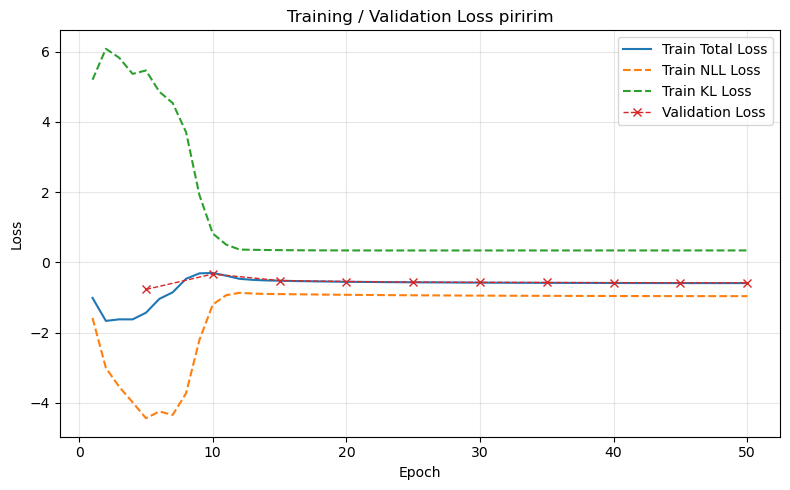

In [146]:
epochs_range = range(1, len(train_total_losses) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs_range, train_total_losses, label='Train Total Loss')
plt.plot(epochs_range, train_nll_losses, label='Train NLL Loss', linestyle='--')
plt.plot(epochs_range, train_kl_losses, label='Train KL Loss', linestyle='--')

if len(val_total_losses) > 0:
    plt.plot(epochs_range[4::5], val_total_losses, 'x--', label='Validation Loss', linewidth=1)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'Training / Validation Loss {conditionedOn}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [147]:
valModel = CVAE(zdim=zdim, system_type=systemType, cond_type=conditionedOn).to(device)

scalers = joblib.load(f"normalizers/normalizers_{systemType}_{conditionedOn}_stride{integratorStride}.pkl")
valModel.attach_normalizers(**scalers)
ckpt = torch.load(f"ckpts/cvae_checkpoint_{systemType}_{conditionedOn}_stride{integratorStride}.pt", map_location="cpu", weights_only=True)
valModel.load_state_dict(ckpt['model_state'])

<All keys matched successfully>

In [148]:
def plot_r_distributions(model, r_next, c_n, n_samples=50000, device=device, Tr=1.0, Tz=1.0):
    """
    Compare benchmark, reconstructed, and generated distributions of r_{n+1}.
    
    Args:
        model: trained CVAE model with attached scalers
        c_n (np.ndarray): conditioning vectors (v_n, r_n), shape [N, c_dim]
        r_next (np.ndarray): true target auxiliary variable, shape [N, 3]
        n_samples: number of samples to draw for visualization
        device: torch device
    """
    # --- Subsample for efficiency ---
    N = len(c_n)
    idx = np.random.choice(N, size=min(n_samples, N), replace=False)
    c_s = c_n[idx]
    r_next_s = r_next[idx]
    
    c_norm = torch.tensor(model.scaler_c.transform(c_s), dtype=torch.float32)
    r_next_norm = torch.tensor(model.scaler_r.transform(r_next_s), dtype=torch.float32)

    # --- Forward pass (reconstruction) ---
    model.eval()
    with torch.no_grad():
        c_t = torch.tensor(c_norm, dtype=torch.float32, device=device)
        r_next_t = torch.tensor(r_next_norm, dtype=torch.float32, device=device)
        dec_out, q, p = model(r_next_t, c_t)
        mu_r, log_sig_r = dec_out
        r_rec_norm = mu_r.cpu().numpy()
        r_rec_norm = mu_r + torch.exp(log_sig_r) * torch.randn_like(mu_r) * Tr
        r_rec = model.scaler_r.inverse_transform(r_rec_norm.cpu())

        # --- Generated samples ---
        r_gen = model.sample(c_s, Tr=Tr, Tz=Tz)

    # --- Plot ---
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    labels = ["r_x", "r_y", "r_z"]
    colors = ["tab:blue", "tab:orange", "tab:green"]
    
    for i, ax in enumerate(axes):
        kde_bench = gaussian_kde(r_next_s[:, i])
        kde_rec = gaussian_kde(r_rec[:, i])
        kde_gen = gaussian_kde(r_gen[:, i].flatten())

        xs = np.linspace(
            min(r_next_s[:, i].min(), r_rec[:, i].min(), r_gen[:, i].min()),
            max(r_next_s[:, i].max(), r_rec[:, i].max(), r_gen[:, i].max()),
            300,
        )
        ax.plot(xs, kde_bench(xs), label="Benchmark", color=colors[i], lw=2)
        ax.plot(xs, kde_rec(xs), "--", color="black", lw=1.5, label="Reconstructed")
        ax.plot(xs, kde_gen(xs), ":", color="red", lw=1.5, label="Generated")

        ax.set_title(f"Distribution of {labels[i]}")
        ax.set_xlabel(labels[i])
        ax.set_ylabel("Density")
        ax.set_xlim(-0.05, 0.05)
        ax.legend()

    plt.tight_layout()
    plt.show()
    
    return r_next_s, r_rec, r_gen
    
def visualize_latent_distributions(model, r_next, c_n, n_samples=50000, device=device):
    """
    Visualize latent space distributions for encoder vs conditional prior.

    Args:
        model: trained CVAE
        c_n (np.ndarray): conditioning variables (r_n, v_n)
        r_next (np.ndarray): true target variables (r_{n+1})
        n_samples (int): number of samples to analyze
        device: torch device
    """
    N = len(c_n)
    idx = np.random.choice(N, size=min(n_samples, N), replace=False)
    c_s = c_n[idx]
    r_next_s = r_next[idx]

    # Normalize
    c_norm = torch.tensor(model.scaler_c.transform(c_s), dtype=torch.float32, device=device)
    r_next_norm = torch.tensor(model.scaler_r.transform(r_next_s), dtype=torch.float32, device=device)

    model.eval()
    with torch.no_grad():
        _, (q_mu, q_logv), _ = model(r_next_norm, c_norm)
        p_mu, p_logv = model.prior_params(c_norm)
        q_mu, q_logv = q_mu.cpu().numpy(), q_logv.cpu().numpy()
        p_mu, p_logv = p_mu.cpu().numpy(), p_logv.cpu().numpy()

    q_std = np.exp(0.5 * q_logv)
    p_std = np.exp(0.5 * p_logv)

    zdim = q_mu.shape[1]

    # --- Plot histograms of latent means ---
    fig, axes = plt.subplots(2, zdim, figsize=(4*zdim, 6))
    for i in range(zdim):
        ax = axes[0, i]
        ax.hist(q_mu[:, i], bins=50, alpha=0.6, label="Encoder μ_q", color="tab:blue")
        ax.hist(p_mu[:, i], bins=50, alpha=0.6, label="Prior μ_p", color="tab:orange")
        ax.set_title(f"Latent dim {i}: means")
        ax.legend()

        ax = axes[1, i]
        ax.hist(q_std[:, i], bins=50, alpha=0.6, label="Encoder σ_q", color="tab:blue")
        ax.hist(p_std[:, i], bins=50, alpha=0.6, label="Prior σ_p", color="tab:orange")
        ax.set_title(f"Latent dim {i}: stds")
        ax.legend()

    plt.tight_layout()
    plt.show()

In [153]:
def plot_r_distributions(model, r_next, c_n,
                         n_samples=50000, device=device,
                         Tr=1.0, Tz=1.0):
    """
    Compare benchmark, reconstructed, and generated distributions of r_{n+1}.

    Handles both:
      - single particle: r_next shape [N, 3]
      - dimer (two particles): r_next shape [N, 6], interpreted as
            (r1_x, r1_y, r1_z, r2_x, r2_y, r2_z)

    Args:
        model: trained CVAE model with attached scalers
        c_n (np.ndarray): conditioning vectors, shape [N, c_dim]
        r_next (np.ndarray): true target auxiliary variable, shape [N, 3] or [N, 6]
        n_samples: number of samples to draw for visualization
        device: torch device
    """
    # --- Subsample for efficiency ---
    N = len(c_n)
    idx = np.random.choice(N, size=min(n_samples, N), replace=False)
    c_s = c_n[idx]
    r_next_s = r_next[idx]

    # dimensionality check
    D = r_next_s.shape[1]
    if D not in (3, 6):
        raise ValueError(f"Expected r_next to have dim 3 or 6, got {D}.")

    # number of particles (1 or 2), each with 3 dims
    n_particles = D // 3

    # --- Normalise ---
    c_norm = torch.tensor(model.scaler_c.transform(c_s), dtype=torch.float32)
    r_next_norm = torch.tensor(model.scaler_r.transform(r_next_s), dtype=torch.float32)

    # --- Forward pass (reconstruction) ---
    model.eval()
    with torch.no_grad():
        c_t = torch.tensor(c_norm, dtype=torch.float32, device=device)
        r_next_t = torch.tensor(r_next_norm, dtype=torch.float32, device=device)

        dec_out, q, p = model(r_next_t, c_t)
        mu_r, log_sig_r = dec_out
        r_rec_norm_t = mu_r + torch.exp(log_sig_r) * torch.randn_like(mu_r) * Tr
        
        r_rec = model.scaler_r.inverse_transform(r_rec_norm_t.cpu().numpy())

        # --- Generated samples (already returns physical units) ---
        r_gen = model.sample(c_s, Tr=Tr, Tz=Tz)  # shape [N, D]

    # --- Plot ---
    # rows = n_particles (1 or 2), cols = 3 (x,y,z)
    fig, axes = plt.subplots(n_particles, 3, figsize=(14, 4 * n_particles), sharey=False)

    # make axes always 2D for uniform indexing
    if n_particles == 1:
        axes = np.expand_dims(axes, axis=0)   # shape -> [1, 3]

    coord_labels = ["x", "y", "z"]
    colors = ["tab:blue", "tab:orange", "tab:green"]

    for p in range(n_particles):
        for j in range(3):
            dim_idx = p * 3 + j  # 0..2 for particle 1, 3..5 for particle 2
            ax = axes[p, j]

            # KDEs for benchmark, reconstructed, generated
            kde_bench = gaussian_kde(r_next_s[:, dim_idx])
            kde_rec   = gaussian_kde(r_rec[:, dim_idx])
            kde_gen   = gaussian_kde(r_gen[:, dim_idx])

            xs = np.linspace(
                min(r_next_s[:, dim_idx].min(), r_rec[:, dim_idx].min(), r_gen[:, dim_idx].min()),
                max(r_next_s[:, dim_idx].max(), r_rec[:, dim_idx].max(), r_gen[:, dim_idx].max()),
                300,
            )

            ax.plot(xs, kde_bench(xs), label="Benchmark", color=colors[j], lw=2)
            ax.plot(xs, kde_rec(xs), "--", color="black", lw=1.5, label="Reconstructed")
            ax.plot(xs, kde_gen(xs), ":", color="red", lw=1.5, label="Generated")

            part_label = f"r{p+1}_{coord_labels[j]}" if n_particles == 2 else f"r_{coord_labels[j]}"
            ax.set_title(f"Distribution of {part_label}")
            ax.set_xlabel(part_label)
            ax.set_ylabel("Density")
            ax.legend()

            # optional fixed x-limits (keep if you like; otherwise comment out)
            ax.set_xlim(-0.05, 0.05)

    plt.tight_layout()
    plt.show()

    return r_next_s, r_rec, r_gen

In [154]:
val_loader_full = DataLoader(val_ds, batch_size=8192, shuffle=False)
all_r, all_c = [], []

for r_win, c_win in val_loader_full:
    r_flat = r_win.reshape(-1, r_win.shape[-1])
    c_flat = c_win.reshape(-1, c_win.shape[-1])
    all_r.append(r_flat)
    all_c.append(c_flat)

r_next_val = torch.cat(all_r, dim=0)
c_val = torch.cat(all_c, dim=0)

r_val_ph = valModel.scaler_r.inverse_transform(r_next_val)
c_val_ph = valModel.scaler_c.inverse_transform(c_val)

/tmp/ipykernel_2873585/189791530.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  c_t = torch.tensor(c_norm, dtype=torch.float32, device=device)
/tmp/ipykernel_2873585/189791530.py:41: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  r_next_t = torch.tensor(r_next_norm, dtype=torch.float32, device=device)


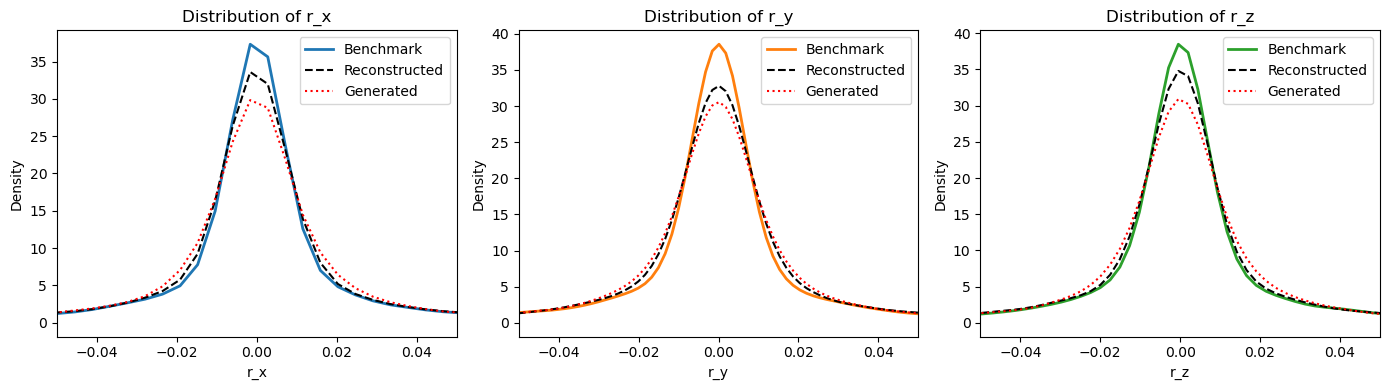

In [155]:
# Assume you have:
# r_n, v_n, r_next = benchmark arrays (each [N, idim])
# model = trained CVAE with attached scalers

r_bench, r_rec, r_gen = plot_r_distributions(valModel, r_val_ph, c_val_ph, n_samples=20000, Tr=1, Tz=1)

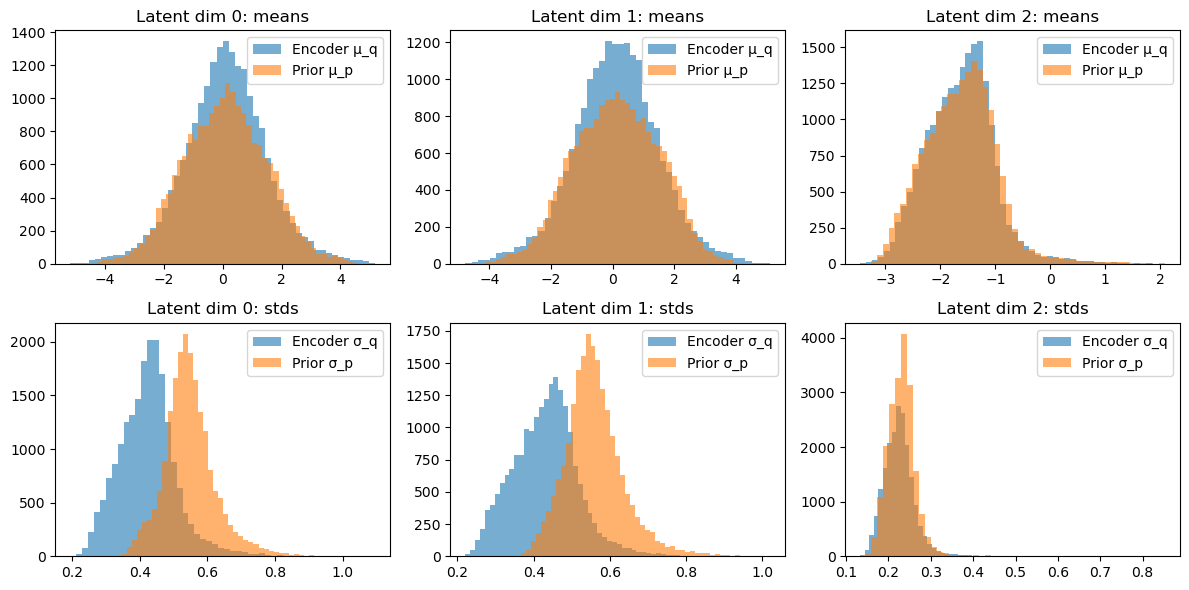

In [156]:
# Assuming you have arrays from benchmark data
# r_n, v_n, r_next -> each [N, 3]
visualize_latent_distributions(valModel, r_val_ph, c_val_ph, n_samples=20000)

In [38]:
batch = next(iter(val_loader))
r_nxt_b, c_t = [x.to(device) for x in batch]

with torch.no_grad():
    dec_out, (q_mu,q_logv), (p_mu,p_logv) = valModel(r_nxt_b, c_t)
    q_std = torch.exp(0.5*q_logv).mean().item()
    p_std = torch.exp(0.5*p_logv).mean().item()
    mu_r, log_sig_r = dec_out
    r_std = torch.exp(log_sig_r).mean().item()
print(f"mean q_std={q_std:.3f}  p_std={p_std:.3f}  decoder_sigma={r_std:.3f}")

mean q_std=0.826  p_std=1.016  decoder_sigma=0.330


In [39]:
def stats(x): 
    x = x.detach().cpu().numpy().reshape(-1)
    qs = np.quantile(x, [0.1,0.5,0.9])
    return f"mean={x.mean():.3f} q10={qs[0]:.3f} q50={qs[1]:.3f} q90={qs[2]:.3f}"
print("p_std:", stats(torch.exp(0.5*p_logv)))
print("q_std:", stats(torch.exp(0.5*q_logv)))
print("dec σ:", stats(torch.exp(log_sig_r)))

p_std: mean=1.016 q10=0.849 q50=0.979 q90=1.284
q_std: mean=0.826 q10=0.533 q50=0.850 q90=1.030
dec σ: mean=0.330 q10=0.176 q50=0.266 q90=0.563
